<a href="https://colab.research.google.com/github/nicolasspaniol/deep-learning-pa1/blob/main/notebooks/part0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [44]:
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt

import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

In [45]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

# **Parte 0 - Teste Unitário Sintético**

In [4]:
class SyntheticEllipseDataset(Dataset):
    def __init__(self, num_samples=500, img_size=128):
        self.num_samples = num_samples
        self.img_size = img_size

    def __len__(self):
        return self.num_samples

    def _generate_sample(self):
        size = self.img_size
        img = np.ones((size, size, 3), dtype=np.uint8) * 255
        mask = np.zeros((size, size), dtype=np.uint8)

        num_ellipses = random.randint(5, 20)
        for i in range(num_ellipses):
            center = (random.randint(10, size-10), random.randint(10, size-10))
            axes = (random.randint(5, 15), random.randint(5, 15))
            angle = random.randint(0, 180)
            gray = random.randint(10, 180)

            cv2.ellipse(img, center, axes, angle, 0, 360, (gray, gray, gray), -1)
            cv2.ellipse(mask, center, axes, angle, 0, 360, 255, -1)

        noise = np.random.normal(0, 30, img.shape)
        img = np.clip(img + noise, 0, 255).astype(np.uint8)

        return img, mask

    def __getitem__(self, idx):
        img, mask = self._generate_sample()

        img_t = torch.from_numpy(img).permute(2, 0, 1).float() / 255.0
        mask_t = torch.from_numpy(mask).float() / 255.0

        return img_t, mask_t

(128, 128, 3) (128, 128)
float32 float32
1.0 0.0 1.0 0.0


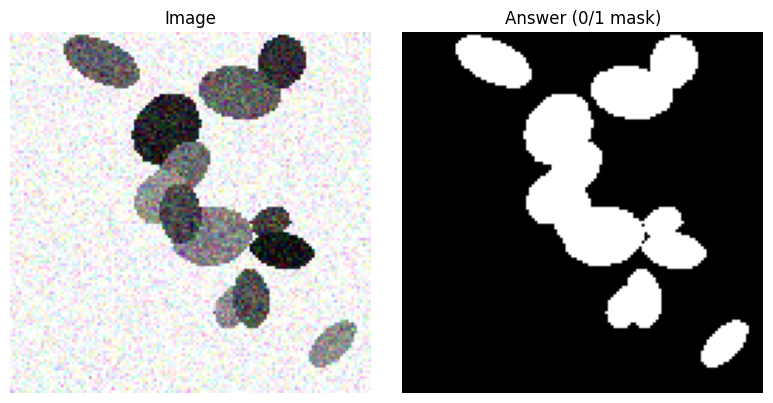

In [68]:
# Exemplo de uso

dataset = SyntheticEllipseDataset(num_samples=1)

# Visualizando uma amostra
img, mask = dataset[0]

img = img.permute(1, 2, 0).numpy()
mask = mask.numpy()

print(img.shape, mask.shape)
print(img.dtype, mask.dtype)
print(img.max(), img.min(), mask.max(), mask.min())

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img)
axes[0].set_title("Image")
axes[0].axis("off")

axes[1].imshow(mask, cmap="gray")
axes[1].set_title("Answer (0/1 mask)")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# **Parte 1 - Baseline de Segmentação Semântica**

In [46]:
# Treinem uma das arquiteturas da aula para segmentação binária (fundo vs. objeto). Reportem IoU e Dice .
# 2. Extraiam instâncias pelo método ingênuo: limiar + componentes conexos.

class ResUNetEncoderBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, stride: int=2):
        super().__init__()

        self.seq = nn.Sequential(
            nn.BatchNorm2d(in_channels),
            nn.ReLU(),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
        )

        self.shortcut = nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride)

    def forward(self, x):
        return self.seq(x) + self.shortcut(x)


class ResUNetDecoderBlock(nn.Module):
    def __init__(self, in_channels: int, out_channels: int, skip_channels: int):
        super().__init__()

        self.seq = nn.Sequential(
            nn.BatchNorm2d(in_channels + skip_channels),
            nn.ReLU(),
            nn.Conv2d(in_channels + skip_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
        )

        # up sampling
        self.ups = nn.Sequential(
            nn.UpsamplingBilinear2d(scale_factor=2),
            nn.Conv2d(in_channels, in_channels, kernel_size=3, padding=1)
        )

        self.shortcut = nn.Conv2d(in_channels + skip_channels, out_channels, kernel_size=1)

    # 'skip' aqui é o tensor de skip connection vindo
    # das saídas intermediárias do encoder
    def forward(self, x, skip):
        x = self.ups(x)
        x = torch.cat([x, skip], dim=1) # concat na dimensão 'C'
        return self.seq(x) + self.shortcut(x)


class ResUNet(nn.Module):
    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()

        self.enc0 = ResUNetEncoderBlock(in_channels, 64, stride=1)
        self.enc1 = ResUNetEncoderBlock(64, 128)
        self.enc2 = ResUNetEncoderBlock(128, 256)

        self.bridge = ResUNetEncoderBlock(256, 512)

        self.dec0 = ResUNetDecoderBlock(512, 256, 256)
        self.dec1 = ResUNetDecoderBlock(256, 128, 128)
        self.dec2 = ResUNetDecoderBlock(128, 64, 64)

        self.ending = nn.Sequential(
            nn.LazyConv2d(out_channels, kernel_size=1),
            # nn.Sigmoid() -- vamos usar a saída em logits
        )

    def forward(self, x):
        # encoder
        out0 = self.enc0(x)
        out1 = self.enc1(out0)
        out2 = self.enc2(out1)
        # ponte
        y = self.bridge(out2)
        # decoder
        y = self.dec0(y, out2)
        y = self.dec1(y, out1)
        y = self.dec2(y, out0)

        return self.ending(y)

In [7]:
# Instanciando o modelo
model = ResUNet(3, 1).to(device)

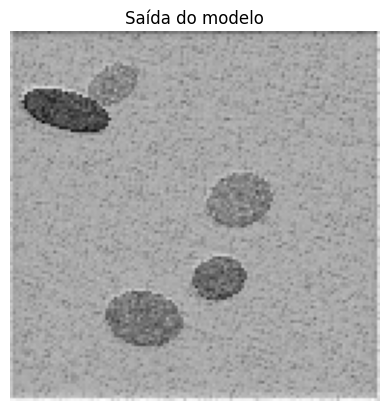

In [8]:
# Teste

model.eval()

dataset = SyntheticEllipseDataset(num_samples=1)
for img, mask in DataLoader(dataset):
    img, mask = img.to(device), mask.to(device)

    y = F.sigmoid(model(img))

    # mesmo número de datapoints
    assert y.shape[0] == img.shape[0]
    # shape[1] é o número de canais, que pode variar
    # mesma resolução
    assert y.shape[2] == img.shape[2]
    assert y.shape[3] == img.shape[3]

    fig, ax = plt.subplots()
    ax.imshow(y[0,0].detach().cpu().numpy(), cmap="gray")
    ax.set_title("Saída do modelo")
    ax.axis("off")
    plt.show()

    break

In [62]:
# Treinando o modelo no dataset sintético (teste unitário)

dataset = SyntheticEllipseDataset(num_samples=512)
loader = DataLoader(dataset, batch_size=16, shuffle=True)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-2)

model.train()
for batch, (X, y) in enumerate(loader):
    X, y = X.to(device), y.to(device)

    y_hat = model(X).squeeze(1)
    loss = loss_fn(y_hat, y)

    loss.backward()
    optimizer.step()
    optimizer.zero_grad()

    if batch % 5 == 0:
        print(f'{batch} - loss={loss}')

0 - loss=0.7746294736862183
5 - loss=0.40929242968559265
10 - loss=0.26816853880882263
15 - loss=0.19603510200977325
20 - loss=0.1569783240556717
25 - loss=0.12302695214748383
30 - loss=0.10891322046518326


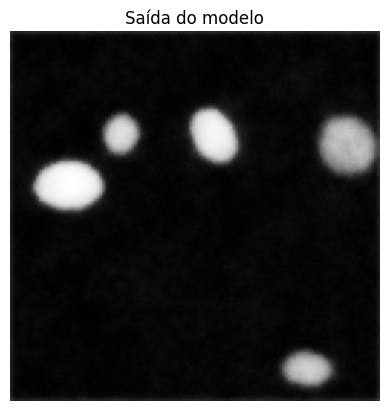

In [63]:
# Teste de sanidade

model.eval()

dataset = SyntheticEllipseDataset(num_samples=1)
for img, mask in DataLoader(dataset):
    img, mask = img.to(device), mask.to(device)

    y = F.sigmoid(model(img))

    fig, ax = plt.subplots()
    ax.imshow(y[0,0].detach().cpu().numpy(), cmap="gray")
    ax.set_title("Saída do modelo")
    ax.axis("off")
    plt.show()

    break

In [10]:
# Carregando os dados: BBBC038
!wget https://data.broadinstitute.org/bbbc/BBBC038/stage1_train.zip -P ./data
!cd data && unzip -q stage1_train.zip -d stage1_train

--2026-09-03 12:51:34--  https://data.broadinstitute.org/bbbc/BBBC038/stage1_train.zip
Resolving data.broadinstitute.org (data.broadinstitute.org)... 69.173.68.137
Connecting to data.broadinstitute.org (data.broadinstitute.org)|69.173.68.137|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 82923446 (79M) [application/zip]
Saving to: ‘./data/stage1_train.zip’

stage1_train.zip    100%[===================>]  79.08M  15.4MB/s    in 6.6s    

2026-09-03 12:51:41 (12.0 MB/s) - ‘./data/stage1_train.zip’ saved [82923446/82923446]



In [71]:
import os
from pathlib import Path
import numpy as np
import torch
from skimage.io import imread
from skimage.transform import resize

IMG_SIZE = 128

class BBBC038Dataset(Dataset):
    def __init__(self):
        self.train_dir = Path("data/stage1_train")
        self.ids = os.listdir(self.train_dir)

    def __len__(self):
        return len(self.ids)

    def __getitem__(self, idx):
        id = self.ids[idx]
        self.mask_dir = self.train_dir / id / "masks"
        img_path = self.train_dir / id / "images" / f"{id}.png"
        image = imread(img_path)[..., :3] / 255
        masks = [imread(self.mask_dir / f) for f in os.listdir(self.mask_dir)]
        mask = np.max(masks, axis=0) / 255

        image = resize(image, (IMG_SIZE, IMG_SIZE), preserve_range=True)
        mask = resize(mask, (IMG_SIZE, IMG_SIZE), order=0, preserve_range=True, anti_aliasing=False).astype(np.uint8)

        image = torch.from_numpy(image).permute(2, 0, 1).contiguous().float()
        mask = torch.from_numpy(mask[..., None]).permute(2, 0, 1)[0].contiguous().float()

        return image, mask

(128, 128, 3) (128, 128)
float32 float32
0.8331557 0.0 1.0 0.0


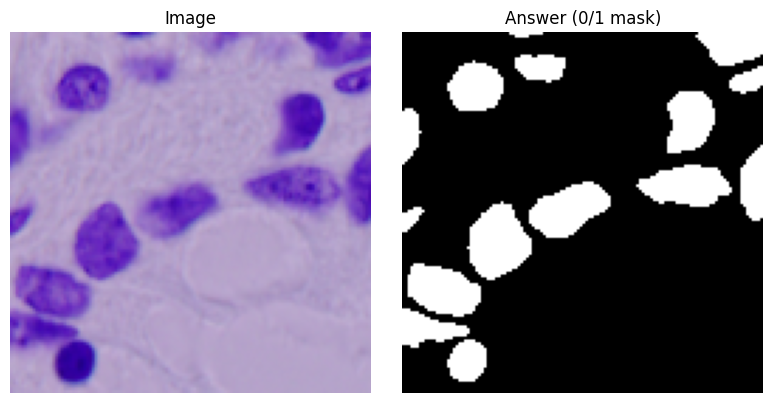

In [82]:
# Testando import do dataset

dataset = BBBC038Dataset()
for img, mask in DataLoader(dataset, shuffle=True):
    img, mask = img[0], mask[0]

    img = img.permute(1, 2, 0).numpy()
    mask = mask.numpy()

    print(img.shape, mask.shape)
    print(img.dtype, mask.dtype)
    print(img.max(), img.min(), mask.max(), mask.min())

    fig, axes = plt.subplots(1, 2, figsize=(8, 4))
    axes[0].imshow(img)
    axes[0].set_title("Image")
    axes[0].axis("off")

    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title("Answer (0/1 mask)")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()

    break

In [78]:
# Treinando o modelo no dataset real

model = ResUNet(3, 1).to(device)

dataset = BBBC038Dataset()
loader = DataLoader(dataset, batch_size=16, shuffle=True)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)

model.train()
for epoch in range(5):
    for batch, (X, y) in enumerate(loader):
        X, y = X.to(device), y.to(device)

        y_hat = model(X).squeeze(1)
        loss = loss_fn(y_hat, y)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 5 == 0:
            print(f'{epoch}/{batch} - loss={loss}')

0/0 - loss=0.7810137867927551
0/5 - loss=0.6646860837936401
0/10 - loss=0.5969329476356506
0/15 - loss=0.5355188250541687
0/20 - loss=0.4881451427936554
0/25 - loss=0.4392276704311371
0/30 - loss=0.39133310317993164
0/35 - loss=0.4039061665534973
0/40 - loss=0.3262839913368225
1/0 - loss=0.3854113817214966
1/5 - loss=0.2770293951034546
1/10 - loss=0.294238805770874
1/15 - loss=0.23194873332977295
1/20 - loss=0.21098622679710388
1/25 - loss=0.23213738203048706
1/30 - loss=0.2769164741039276
1/35 - loss=0.20799702405929565
1/40 - loss=0.16491848230361938
2/0 - loss=0.2111641764640808
2/5 - loss=0.23429031670093536
2/10 - loss=0.2500075399875641
2/15 - loss=0.17132192850112915
2/20 - loss=0.15531224012374878
2/25 - loss=0.18015503883361816
2/30 - loss=0.17588424682617188
2/35 - loss=0.19132709503173828
2/40 - loss=0.11379396170377731
3/0 - loss=0.21704354882240295
3/5 - loss=0.13722646236419678
3/10 - loss=0.1690671592950821
3/15 - loss=0.12931320071220398
3/20 - loss=0.17300361394882202


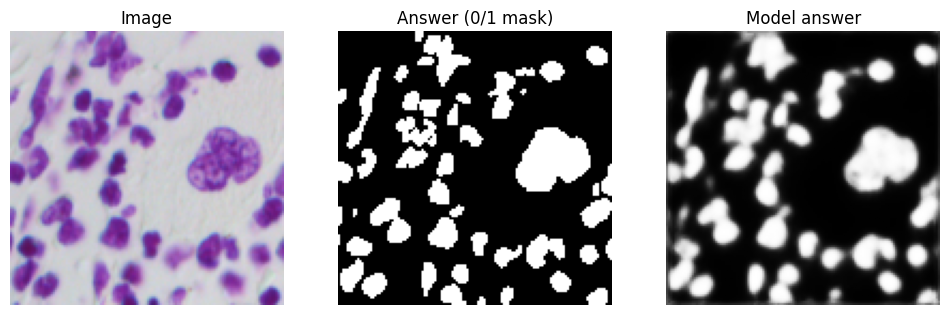

In [100]:
# Teste de sanidade

model.eval()

dataset = BBBC038Dataset()
for img, mask in DataLoader(dataset, shuffle=True):
    img, mask = img.to(device), mask.to(device)

    y = F.sigmoid(model(img))[0,0].cpu().detach().numpy()

    img = img[0].permute(1, 2, 0).cpu().detach().numpy()
    mask = mask[0].cpu().detach().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(img)
    axes[0].set_title("Image")
    axes[0].axis("off")

    axes[1].imshow(mask, cmap="gray")
    axes[1].set_title("Answer (0/1 mask)")
    axes[1].axis("off")

    axes[2].imshow(y, cmap="gray")
    axes[2].set_title("Model answer")
    axes[2].axis("off")

    plt.show()

    break